In [1]:
import os
import sys

if "../" not in sys.path:
    sys.path.insert(0, "../")

In [2]:
import coremltools.optimize as cto
import numpy as np
import coremltools as ct
from coremltools.converters.mil import Builder as mb
import coremltools.converters.mil as mil

scikit-learn version 1.6.1 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
Torch version 2.7.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.5.0 is the most recent version that has been tested.
W0708 13:48:20.129000 46672 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
from layers import RMSNorm, rmsnorm_animal_style

In [17]:
wc = np.random.normal(scale=0.1, size=(2048, 2048, 1, 1)).astype(np.float16)

In [120]:
dim = 2048
NORM_EPS = np.finfo(np.float16).tiny
inp_spec = mb.TensorSpec((1, dim, 1, 32), dtype=mil.input_types.types.fp16)
state_spec = mb.StateTensorSpec(
    (1,),
    dtype=mil.input_types.types.fp16,
)

@mb.program(
    input_specs=[inp_spec, state_spec],
    opset_version=mil.builder.AvailableTarget.iOS18,
)
def absmax_program(x, null_state):
    read_state = mb.read_state(input=null_state) # just to make it runs on ANE
    xc = mb.conv(x=x, weight=wc)
    m = mb.reduce_max(x=xc, axes=(0, 1, 3))
    read_state = mb.slice_update(
        x=read_state,
        update=m,
        begin=[0],
        end=[1],
        begin_mask=[False],
        end_mask=[False],
        squeeze_mask=[False],
    )
    read_state = mb.coreml_update_state(value=read_state, state=null_state)
    mean = mb.reduce_mean(x=x, axes=(1,))
    norm_layer = RMSNorm(None, axes=(1,), eps=NORM_EPS)
    return norm_layer(x, ""), read_state, mean

@mb.program(
    input_specs=[inp_spec, state_spec],
    opset_version=mil.builder.AvailableTarget.iOS18,
)
def animal_norm_program(x, null_state):
    read_state = mb.read_state(input=null_state) # just to make it runs on ANE
    xc = mb.conv(x=x, weight=wc)
    m = mb.reduce_max(x=xc, axes=(0, 1, 3))
    read_state = mb.slice_update(
        x=read_state,
        update=m,
        begin=[0],
        end=[1],
        begin_mask=[False],
        end_mask=[False],
        squeeze_mask=[False],
    )
    read_state = mb.coreml_update_state(value=read_state, state=null_state)
    mean = mb.reduce_mean(x=x, axes=(1,))
    x = rmsnorm_animal_style(x, axis=1, prefix="")
    x = mb.split(x=x, axis=1, num_splits=2)[0]
    return x, read_state, mean

print(absmax_program)
print(animal_norm_program)


main[CoreML8](%x: (1, 2048, 1, 32, fp16)(Tensor),
              %null_state: (1,fp16)(State)) {
  block54() {
    %read_state_1: (1,fp16)(Tensor) = read_state(input=%null_state, name="read_state_1")
    %conv_1: (1, 2048, 1, 32, fp16)(Tensor) = conv(x=%x, weight=%conv_1_weight_0, strides=[1, 1], pad_type="valid", pad=[0, 0, 0, 0], dilations=[1, 1], groups=1, name="conv_1")
    %reduce_max_1: (1,fp16)(Tensor) = reduce_max(x=%conv_1, axes=(0, 1, 3), keep_dims=False, name="reduce_max_1")
    %slice_update_1: (1,fp16)(Tensor) = slice_update(x=%read_state_1, update=%reduce_max_1, begin=[0], end=[1], begin_mask=[False], end_mask=[False], squeeze_mask=[False], name="slice_update_1")
    %coreml_update_state_1: (1,fp16)(Tensor) = coreml_update_state(state=%null_state, value=%slice_update_1, name="coreml_update_state_1")
    %reduce_mean_0: (1, 1, 32, fp16)(Tensor) = reduce_mean(x=%x, axes=(1,), keep_dims=False, name="reduce_mean_0")
    %rmsnorm_abs: (1, 2048, 1, 32, fp16)(Tensor) = abs(x=%x,

In [121]:
absmax_mlmodel = ct.convert(
    absmax_program,
    compute_units=ct.ComputeUnit.CPU_AND_NE,
    compute_precision=ct.precision.FLOAT16,
    minimum_deployment_target=ct.target.iOS18,
    package_dir="./absmax_rmsnorm.mlpackage",
)

Running MIL frontend_milinternal pipeline: 0 passes [00:00, ? passes/s]
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 592.53 passes/s]


In [122]:
animal_mlmodel = ct.convert(
    animal_norm_program,
    compute_units=ct.ComputeUnit.CPU_AND_NE,
    compute_precision=ct.precision.FLOAT16,
    minimum_deployment_target=ct.target.iOS18,
    package_dir="./animal_rmsnorm.mlpackage",
)

Running MIL frontend_milinternal pipeline: 0 passes [00:00, ? passes/s]
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 555.59 passes/s]


In [21]:
import torch

In [34]:
norm_layer = torch.nn.RMSNorm(2048, 1e-6).eval()

In [26]:
state = absmax_mlmodel.make_state()

In [ ]:
import matplotlib.pyplot as plt

In [123]:
def sample_with_outliers(shape, pct_outliers=5e-3):
    # --- 1. Define the parameters ---
    total_num_samples = np.prod(shape)
    num_outliers = int(np.ceil(total_num_samples * pct_outliers))
    print("Num Total Elements:", total_num_samples, ", Number of Outliers:", num_outliers)
    num_main_samples = total_num_samples - num_outliers
    outlier_magnitude = 65_000 # float16 limit is ~65_000

    # --- 2. Generate the data ---
    # Main data: standard normal distribution
    main_data = np.random.randn(num_main_samples)

    # Outlier data: large positive and negative values
    outliers = np.clip((np.random.rand(num_outliers)) * 1 * outlier_magnitude * 1.2, min=-outlier_magnitude, max=outlier_magnitude)

    # --- 3. Combine and shuffle ---
    combined_data = np.concatenate([main_data, outliers])
    np.random.shuffle(combined_data)

    return combined_data.reshape(shape)

In [128]:
inp_np = sample_with_outliers((1, 2048, 1, 32))

Num Total Elements: 65536 , Number of Outliers: 328


In [129]:
np.sort(inp_np.reshape(-1))[:-100:-1]

array([65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
       65000.        , 65000.        , 65000.        , 65000.        ,
      

(array([6.5218e+04, 1.1000e+01, 1.3000e+01, 8.0000e+00, 1.7000e+01,
        1.6000e+01, 1.3000e+01, 6.0000e+00, 1.6000e+01, 1.4000e+01,
        1.4000e+01, 1.3000e+01, 1.6000e+01, 1.2000e+01, 8.0000e+00,
        1.6000e+01, 2.4000e+01, 1.6000e+01, 1.6000e+01, 6.9000e+01]),
 array([-4.17354146e+00,  3.24603514e+03,  6.49624381e+03,  9.74645249e+03,
         1.29966612e+04,  1.62468698e+04,  1.94970785e+04,  2.27472872e+04,
         2.59974959e+04,  2.92477046e+04,  3.24979132e+04,  3.57481219e+04,
         3.89983306e+04,  4.22485393e+04,  4.54987479e+04,  4.87489566e+04,
         5.19991653e+04,  5.52493740e+04,  5.84995826e+04,  6.17497913e+04,
         6.50000000e+04]),
 <BarContainer object of 20 artists>)

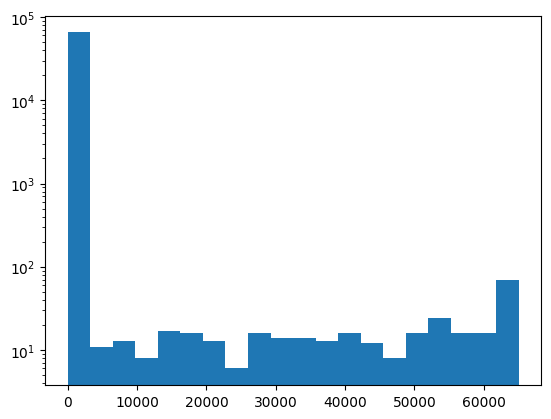

In [130]:
plt.hist(inp_np.reshape(-1), log=True, bins=20)

In [136]:
torch_inp = torch.from_numpy(inp_np).squeeze(-2).transpose(-1, -2)
fp32_result = norm_layer(torch_inp).transpose(-1, -2).view(-1).detach().numpy()
absmax_prediction = absmax_mlmodel.predict({"x": inp_np}, state) # ["rmsnorm_normalized"].reshape(-1)
animal_prediction = animal_mlmodel.predict({"x": inp_np}, state) # ["split_0_0"].reshape(-1)

absmax_result = absmax_prediction["rmsnorm_normalized"].reshape(-1)
animal_result = animal_prediction["split_0_0"].reshape(-1)
absmax_mean_result = absmax_prediction["reduce_mean_0"].reshape(-1)
animal_mean_result = animal_prediction["reduce_mean_1"].reshape(-1)


abs_fp32 = np.abs(fp32_result)

In [138]:
print(absmax_mean_result)
print(animal_mean_result)

[265.75    333.75    189.75    162.375    72.375   243.      210.625
 143.5     142.25    217.125   133.125   303.5     208.375   143.75
 298.25    283.25    176.125   232.125   163.625   284.5     113.0625
 110.375   206.       98.5625  181.5      50.59375 201.375   198.375
 262.75    319.5     263.25    162.375  ]
[265.75    333.75    189.75    162.375    72.375   243.      210.625
 143.5     142.25    217.125   133.125   303.5     208.375   143.75
 298.25    283.25    176.125   232.125   163.625   284.5     113.0625
 110.375   206.       98.5625  181.5      50.59375 201.375   198.375
 262.75    319.5     263.25    162.375  ]


(array([1.00000e+00, 2.00000e+00, 6.00000e+00, 2.70000e+01, 5.50000e+01,
        1.69000e+02, 1.55000e+02, 6.10000e+01, 5.60000e+01, 6.30000e+01,
        4.90000e+01, 2.60885e+05, 5.30000e+01, 4.30000e+01, 6.30000e+01,
        1.42000e+02, 1.75000e+02, 9.20000e+01, 2.80000e+01, 1.90000e+01]),
 array([-32.79306794, -29.84702012, -26.9009723 , -23.95492449,
        -21.00887667, -18.06282885, -15.11678103, -12.17073321,
         -9.22468539,  -6.27863758,  -3.33258976,  -0.38654194,
          2.55950588,   5.5055537 ,   8.45160152,  11.39764933,
         14.34369715,  17.28974497,  20.23579279,  23.18184061,
         26.12788843]),
 <BarContainer object of 20 artists>)

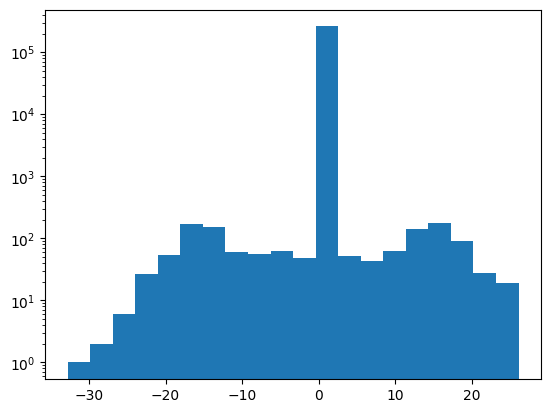

In [103]:
plt.hist(fp32_result, log=True, bins=20)

In [84]:
fp32_result

array([ 1.75836793e-04, -3.21795213e-04,  3.36002992e-05, ...,
       -4.94967963e-04,  6.94257212e-04, -4.64901067e-04], shape=(262144,))

In [118]:
np.max(animal_result)

np.float32(26.125)

In [85]:
absmax_result

array([ 1.7595291e-04, -3.2186508e-04,  3.3617020e-05, ...,
       -4.9543381e-04,  6.9475174e-04, -4.6515465e-04],
      shape=(262144,), dtype=float32)

In [86]:
animal_result

array([ 1.7583370e-04, -3.2186508e-04,  3.3617020e-05, ...,
       -4.9495697e-04,  6.9427490e-04, -4.6515465e-04],
      shape=(262144,), dtype=float32)

(array([2.58323e+05, 1.88100e+03, 6.07000e+02, 3.54000e+02, 1.49000e+02,
        1.54000e+02, 7.90000e+01, 2.80000e+01, 2.20000e+01, 1.40000e+01,
        1.90000e+01, 1.50000e+01, 1.80000e+01, 1.40000e+01, 8.00000e+00,
        1.50000e+01, 9.00000e+00, 1.50000e+01, 1.10000e+01, 4.09000e+02]),
 array([9.23848309e-09, 5.23692226e-02, 1.04738436e-01, 1.57107649e-01,
        2.09476863e-01, 2.61846076e-01, 3.14215290e-01, 3.66584503e-01,
        4.18953716e-01, 4.71322930e-01, 5.23692143e-01, 5.76061357e-01,
        6.28430570e-01, 6.80799784e-01, 7.33168997e-01, 7.85538210e-01,
        8.37907424e-01, 8.90276637e-01, 9.42645851e-01, 9.95015064e-01,
        1.04738428e+00]),
 <BarContainer object of 20 artists>)

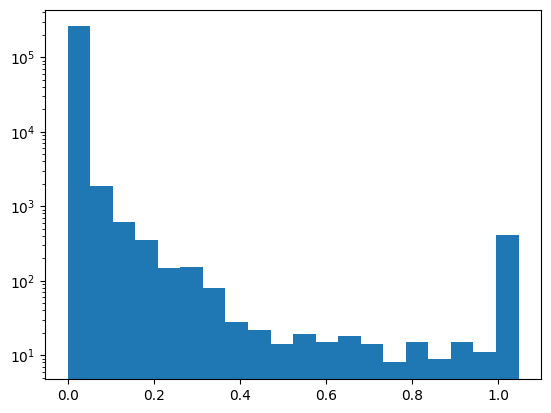

In [ ]:
plt.hist(np.abs(absmax_result - fp32_result) / abs_fp32, log=True, bins=20)

(array([2.61902e+05, 1.17000e+02, 4.10000e+01, 1.50000e+01, 1.20000e+01,
        5.00000e+00, 7.00000e+00, 2.00000e+00, 1.00000e+00, 2.00000e+00,
        1.00000e+00, 1.00000e+00, 1.00000e+00, 2.00000e+00, 0.00000e+00,
        1.00000e+00, 2.00000e+00, 1.00000e+00, 0.00000e+00, 3.10000e+01]),
 array([4.48462682e-12, 5.00000000e-02, 1.00000000e-01, 1.50000000e-01,
        2.00000000e-01, 2.50000000e-01, 3.00000000e-01, 3.50000000e-01,
        4.00000000e-01, 4.50000000e-01, 5.00000000e-01, 5.50000000e-01,
        6.00000000e-01, 6.50000000e-01, 7.00000000e-01, 7.50000000e-01,
        8.00000000e-01, 8.50000000e-01, 9.00000000e-01, 9.50000000e-01,
        1.00000000e+00]),
 <BarContainer object of 20 artists>)

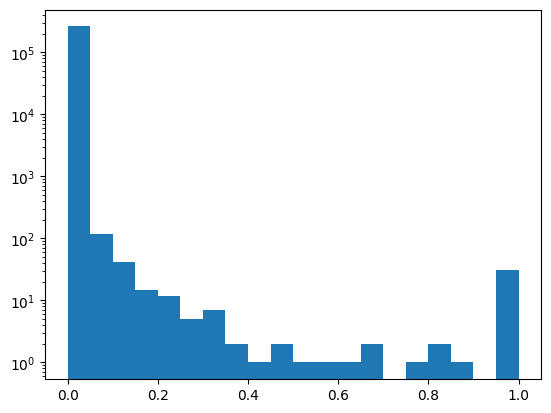

In [88]:
plt.hist(np.abs(animal_result - fp32_result) / abs_fp32, log=True, bins=20)

(array([0.99629974, 0.99711227, 0.99777222, 0.9983902 , 0.99882126,
        0.99916077, 0.99936295, 0.99951553, 0.99966431, 0.99979782,
        0.99982071, 0.9998436 , 0.99986649, 0.99996185, 0.99996948,
        0.99996948, 0.9999733 , 0.99997711, 0.99998474, 1.        ]),
 array([2.02023944e-12, 1.49700314e-03, 2.99400627e-03, 4.49100940e-03,
        5.98801253e-03, 7.48501567e-03, 8.98201880e-03, 1.04790219e-02,
        1.19760251e-02, 1.34730282e-02, 1.49700313e-02, 1.64670345e-02,
        1.79640376e-02, 1.94610407e-02, 2.09580439e-02, 2.24550470e-02,
        2.39520501e-02, 2.54490533e-02, 2.69460564e-02, 2.84430595e-02,
        2.99400627e-02]),
 <BarContainer object of 20 artists>)

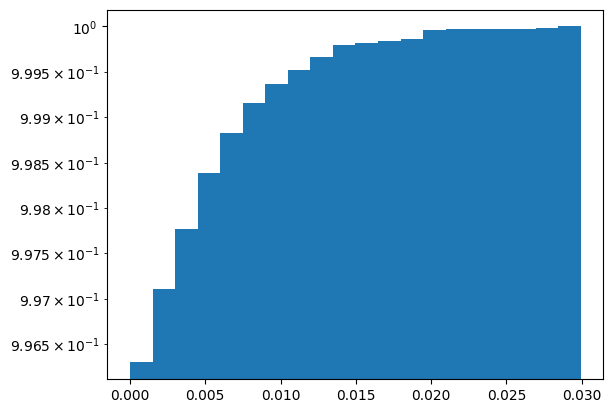

In [93]:
plt.hist(np.abs(absmax_result - fp32_result), log=True, bins=20, density=True, cumulative=True)

(array([0.99677658, 0.99791336, 0.99867249, 0.9992981 , 0.99951172,
        0.99975967, 0.99985123, 0.99993134, 0.99998856, 0.99999237,
        0.99999237, 0.99999619, 0.99999619, 0.99999619, 0.99999619,
        0.99999619, 0.99999619, 0.99999619, 0.99999619, 1.        ]),
 array([6.47946323e-16, 2.15339705e-03, 4.30679409e-03, 6.46019114e-03,
        8.61358819e-03, 1.07669852e-02, 1.29203823e-02, 1.50737793e-02,
        1.72271764e-02, 1.93805734e-02, 2.15339705e-02, 2.36873675e-02,
        2.58407646e-02, 2.79941616e-02, 3.01475587e-02, 3.23009557e-02,
        3.44543528e-02, 3.66077498e-02, 3.87611468e-02, 4.09145439e-02,
        4.30679409e-02]),
 <BarContainer object of 20 artists>)

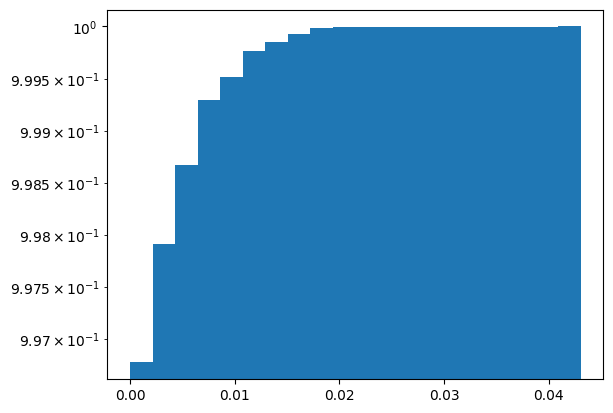

In [95]:
plt.hist(np.abs(animal_result - fp32_result), log=True, bins=20, density=True, cumulative=True)

In [102]:
np.sort(abs_fp32)[:-50:-1]

array([32.79306794, 29.35504482, 27.3172768 , 26.12788843, 26.12788843,
       26.12788843, 26.01272764, 26.01272764, 26.01272764, 25.35751654,
       25.35751654, 25.35751654, 24.89125779, 24.89125779, 24.7149149 ,
       24.58481733, 24.58481733, 24.40141552, 24.40141552, 24.40141552,
       24.18040752, 24.18040752, 24.08198719, 24.08198719, 24.08198719,
       23.3714988 , 23.3714988 , 23.22026578, 23.22026578, 23.22026578,
       23.11839259, 22.88503705, 22.88503705, 22.61438767, 22.61438767,
       22.61438767, 22.61438767, 22.57681506, 22.57681506, 22.57681506,
       22.57681506, 22.55039089, 22.55039089, 22.55039089, 22.23945119,
       22.23945119, 22.23945119, 22.23945119, 22.20961246])

In [ ]:
np.(abs_fp32)

np.float64(-2.747543869068e-07)